## Installing and Importing Packages, and Mounting Google Drive

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import re
import os
import sys
import math

import string
from collections import defaultdict

from google.colab import data_table

In [17]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [18]:
# define source and target languages
source_name = 'English'
target_name = 'Xitsonga'

source_code = 'eng'
target_code = 'tso'

In [19]:
# loading data
main_path = f'/content/drive/My Drive/Research/{source_code}-to-{target_code}/case_for_subword_tokenization'
source_path = f'{main_path}/train_{source_code}.txt'
target_path = f'{main_path}/train_{target_code}.txt'

with open(source_path, 'r', encoding='utf-8') as f:
  source = f.read().splitlines()

with open(target_path, 'r', encoding='utf-8') as f:
  target = f.read().splitlines()

In [20]:
# convert text files containing source and target segments to pandas.DataFrame
df = pd.DataFrame({source_name:source, target_name:target})
N = len(df)
print(f"The number of segment pairs in the parallel corpus: {N}.")

The number of segment pairs in the parallel corpus: 149115.


## Visualising Segment Pairs


In [21]:
# create a new dataframe: length of sentences on each side of the training corpus
df_sent_len = pd.DataFrame({source_name: df[source_name].str.split().apply(len), target_name:df[target_name].str.split().apply(len)})
print("Summary for Training Corpus:")
print(df_sent_len.describe())



Summary for Training Corpus:
             English       Xitsonga
count  149115.000000  149115.000000
mean       10.033377      11.765563
std         6.513688       8.072217
min         1.000000       1.000000
25%         6.000000       7.000000
50%         9.000000      10.000000
75%        12.000000      14.000000
max        40.000000      50.000000


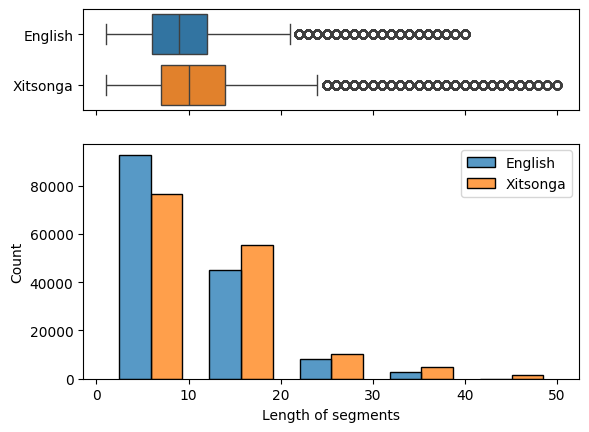

In [22]:
# visualise length of segments in parallel corpus
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.3, .7)})
sns.boxplot(df_sent_len.iloc[:, [0,1]], orient="h", ax=ax_box)
sns.histplot(df_sent_len.iloc[:, [0,1]],
             binwidth=10,
             multiple='dodge',
             shrink=0.7,
             legend=True,
             common_norm=False,
             ax=ax_hist)

# add labels to plots
ax_hist.set_xlabel("Length of segments")

# display plot
plt.show()

### Removing segment pairs with significant source to target ratio w.r.t length of segments in a pair

In [23]:
# add a column to dataframe: length of source segment/length of target segment
df_sent_len = df_sent_len.assign(ratio = df_sent_len[source_name]/df_sent_len[target_name])
print("Summary for Training Corpus:")
print(df_sent_len.describe())

Summary for Training Corpus:
             English       Xitsonga          ratio
count  149115.000000  149115.000000  149115.000000
mean       10.033377      11.765563       0.894146
std         6.513688       8.072217       0.235811
min         1.000000       1.000000       0.300000
25%         6.000000       7.000000       0.750000
50%         9.000000      10.000000       0.882353
75%        12.000000      14.000000       1.000000
max        40.000000      50.000000       2.000000


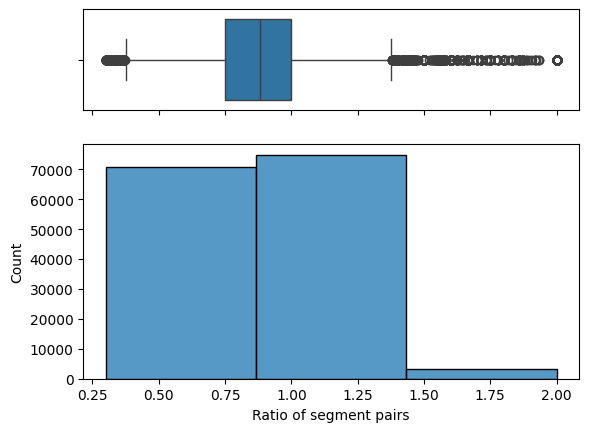

In [24]:
# visualising ratio of source to target segments pairs
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.3, .7)})
sns.boxplot(df_sent_len.iloc[:, 2], orient="h", ax=ax_box)
sns.histplot(df_sent_len.iloc[:, 2],
             binwidth=0.5,
             ax=ax_hist)

# add labels to plots
ax_hist.set_xlabel("Ratio of segment pairs")

# display plot
plt.show()

## Token Count

### Token count (incl. words, numbers and punctuation):

In [25]:
df_tokens_count = df.copy(deep=True)

# create new dataframes: length of words on each side of the parallel corpus
source_tokens_count = defaultdict(int)
target_tokens_count = defaultdict(int)

# counting number of tokens
for segment in df_tokens_count[source_name]:
  for word in segment.split():
    source_tokens_count[word] += 1

for segment in df_tokens_count[target_name]:
  for word in segment.split():
    target_tokens_count[word] += 1

print(f"Number of unique tokens (incl. words, numbers and punctuation) on the {source_name} side is: {len(source_tokens_count)}.")
print(f"Number of tokens (incl. words, numbers and punctuation) on the {source_name} side is: {sum(source_tokens_count.values())}.")
print()
print(f"Number of unique tokens (incl. words, numbers and punctuation) on the {target_name} side is: {len(target_tokens_count)}.")
print(f"Number of tokens (incl. words, numbers and punctuation) on the {target_name} side is: {sum(target_tokens_count.values())}.")

Number of unique tokens (incl. words, numbers and punctuation) on the English side is: 32888.
Number of tokens (incl. words, numbers and punctuation) on the English side is: 1496127.

Number of unique tokens (incl. words, numbers and punctuation) on the Xitsonga side is: 41029.
Number of tokens (incl. words, numbers and punctuation) on the Xitsonga side is: 1754422.


### Comparing length of tokens in source, target and vocabulary tokens:

In [26]:
# loading data
subwords_path = f'/content/drive/My Drive/Research/{source_code}-to-{target_code}/bpe/data-bin/dict.eng.txt'

with open(subwords_path, 'r', encoding='utf-8') as f:
  subwords = f.read().splitlines()


In [27]:
# creating list of subwords and list of subword frequencies
list_of_subwords = []
freq = []
for s in subwords:
  list_of_subwords.append(s.split(" ")[0])
  freq.append(s.split(" ")[1])

# remove special character in subwords
for i in range(len(list_of_subwords)):
  if list_of_subwords[i][-2:] == "@@":
    list_of_subwords[i] = list_of_subwords[i][:-2]

# length of subwords
len_of_subwords = []
for s in list_of_subwords:
  len_of_subwords.append(len(s))

In [28]:
# create a new dataframe: length of subwords
df_subword_len = pd.DataFrame({"": list_of_subwords, "Subwords": len_of_subwords})
print("Summary for Subword Tokens:")
print(df_subword_len.describe())

Summary for Subword Tokens:
          Subwords
count  4156.000000
mean      4.740857
std       2.420525
min       1.000000
25%       3.000000
50%       4.000000
75%       6.000000
max      16.000000


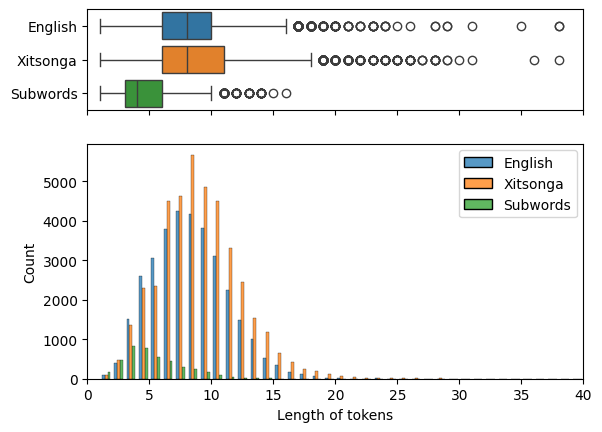

In [29]:
# create a new dataframe: length of whitespace characters on each side of the parallel corpora
source_word_len = pd.DataFrame({word: list(source_tokens_count.keys())})
source_word_len = source_word_len.assign(source_name = source_word_len[word].str.len())
source_word_len = source_word_len.rename(columns={'source_name': source_name})
target_word_len = pd.DataFrame({word: list(target_tokens_count.keys())})
target_word_len = target_word_len.assign(target_name = target_word_len[word].str.len())
target_word_len = target_word_len.rename(columns={'target_name': target_name})
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.3, .7)})

ax_box.set_xlim(0,40)
ax_hist.set_xlim(0,40)
sns.boxplot([source_word_len.iloc[:, 1], target_word_len.iloc[:, 1], df_subword_len.iloc[:, 1]], orient="h", ax=ax_box)
sns.histplot([source_word_len.iloc[:, 1], target_word_len.iloc[:, 1], df_subword_len.iloc[:, 1]],
             binwidth=1,
             multiple='dodge',
             shrink=0.7,
             common_norm=False,
             legend=True,
             ax=ax_hist)

# add labels to plots
ax_hist.set_xlabel("Length of tokens")

# display plot
plt.show()

### Word Cloud of subword Tokens

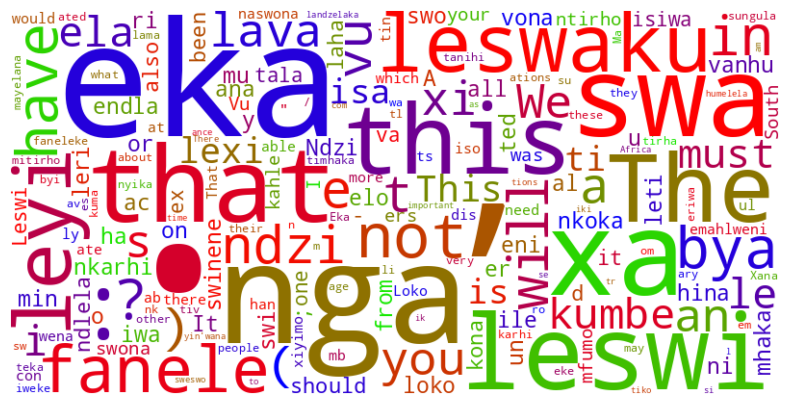

In [30]:
freq = [int(item) for item in freq]
subword_frequencies = dict(zip(list_of_subwords, freq))

# word cloud of subword tokens
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="brg"
)

# Generate the word cloud from the frequency dictionary
wordcloud.generate_from_frequencies(subword_frequencies)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Turn off the axis
plt.show()